In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2
import glob  # Add this line at the beginning of your script
from tqdm import tqdm
import numpy as np
import tensorflow as tf

# Puis importez ImageDataGenerator normalement
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
import glob  # Required for file path searching
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Taille cible des images
IMG_SIZE = (48, 48)

# Fonction d'affichage d'un échantillon d'images
def display_images(images, labels, label_dict, title, max_images=10):
    plt.figure(figsize=(15, 4))
    for i in range(min(len(images), max_images)):
        plt.subplot(1, max_images, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(label_dict[labels[i]])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Fonction complète de chargement, affichage et prétraitement
def load_data(data_dir, max_images_display=10):
    images = []
    labels = []
    label_dict = {}

    # Liste des dossiers d'émotions (classes)
    emotion_dirs = sorted([d for d in os.listdir(data_dir)
                         if os.path.isdir(os.path.join(data_dir, d))])
    
    # Dictionnaire des labels
    label_dict = {i: emotion for i, emotion in enumerate(emotion_dirs)}

    print("Classes détectées :", label_dict)

    for label, emotion in enumerate(emotion_dirs):
        emotion_dir = os.path.join(data_dir, emotion)
        paths = glob.glob(os.path.join(emotion_dir, '*.*'))  # FIXED: Using glob.glob()

        for path in tqdm(paths, desc=f"Chargement [{emotion}]"):
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # Affiche la taille originale des premières images
                if len(images) < max_images_display:
                    print(f"{emotion} - {os.path.basename(path)} : {img.shape}")
                images.append(img)
                labels.append(label)

    # Affichage des images originales
    display_images(images, labels, label_dict, "Images originales (non redimensionnées)", max_images_display)

    # Redimensionnement + normalisation
    images_resized = [cv2.resize(img, IMG_SIZE) / 255.0 for img in images]
    images_resized = np.array(images_resized).reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)
    labels = np.array(labels)

    # Affichage des images redimensionnées
    display_images(images_resized.squeeze(), labels, label_dict, "Images redimensionnées et normalisées", max_images_display)

    return images_resized, labels, label_dict

Classes détectées : {0: 'Anger', 1: 'Disgust', 2: 'Fear', 3: 'Sadness', 4: 'Surprise', 5: 'bonheur'}


Chargement [Anger]:   0%|                                                             | 2/3198 [00:00<06:59,  7.62it/s]

Anger - 0001_anger_20241226_141727.png : (1024, 1024)
Anger - 0002_anger_20241229_194617.png : (1024, 1024)


Chargement [Anger]:   0%|                                                             | 4/3198 [00:00<06:49,  7.81it/s]

Anger - 0003_anger_20241226_013350.png : (1024, 1024)
Anger - 0004_anger_20241229_192052.png : (1024, 1024)


...

Chargement [Anger]:   0%|▏                                                            | 8/3198 [00:01<06:32,  8.14it/s]

Anger - 0007_anger_20241225_182011.png : (1024, 1024)
Anger - 0008_anger_20241227_172526.png : (1024, 1024)


Chargement [Anger]:   0%|▏                                                           | 11/3198 [00:01<05:46,  9.18it/s]

Anger - 0009_anger_20241226_033910.png : (1024, 1024)
Anger - 0010_anger_20241227_170400.png : (1024, 1024)


Chargement [bonheur]: 100%|████████████████████████████████████████████████████████| 2376/2376 [03:23<00:00, 11.70it/s]


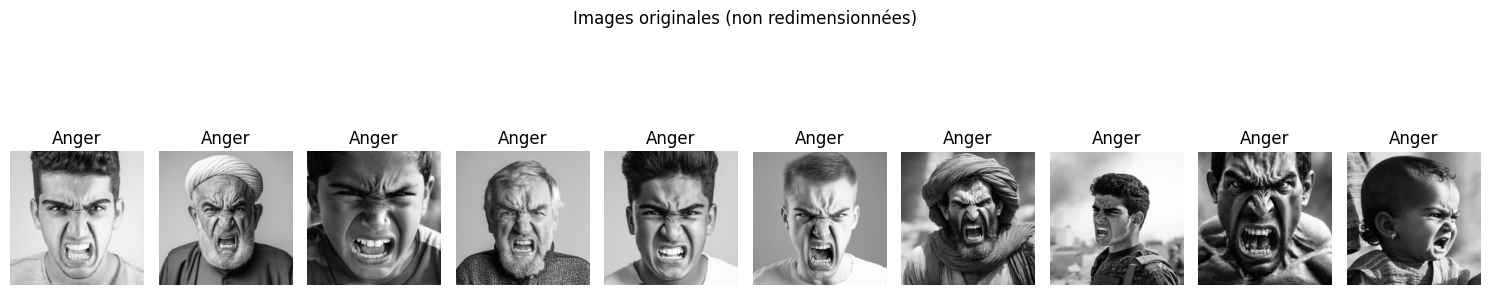

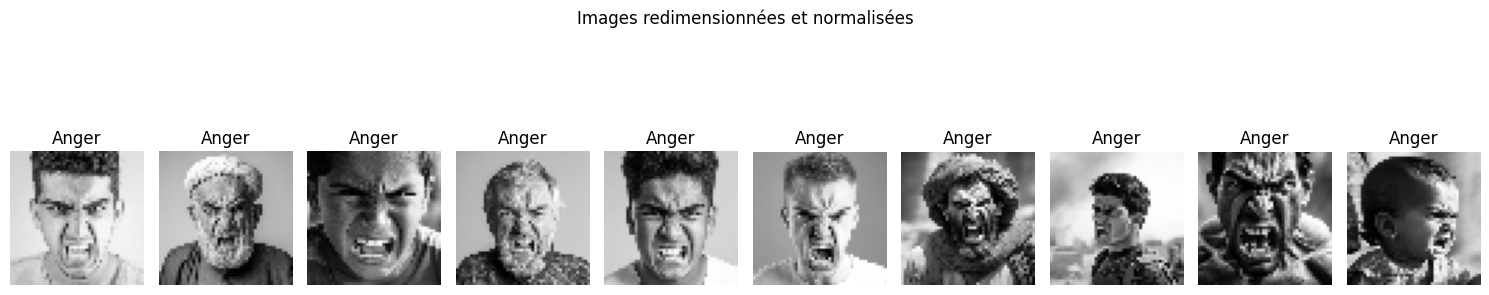

In [3]:
DATA_DIR = "data_emotion"  # dossier contenant les dossiers des émotions
X, y, label_dict = load_data(DATA_DIR)


In [7]:
X.shape

(17000, 48, 48, 1)

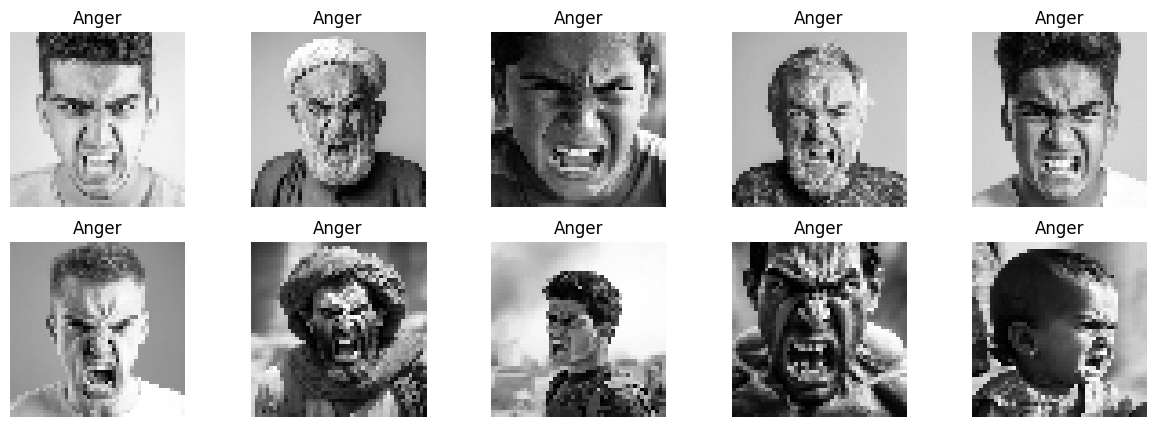

In [4]:
# Visualiser quelques exemples
plt.figure(figsize=(15, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(label_dict[y[i]])
    plt.axis('off')
plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(labels, label_dict):
    class_counts = np.bincount(labels)
    class_labels = [label_dict[i] for i in range(len(class_counts))]

    plt.figure(figsize=(6, 6))
    plt.pie(class_counts, labels=class_labels, autopct='%1.1f%%', startangle=140)
    plt.title("Répartition des classes (équilibre)")
    plt.axis('equal')  # Pour un cercle parfait
    plt.show()


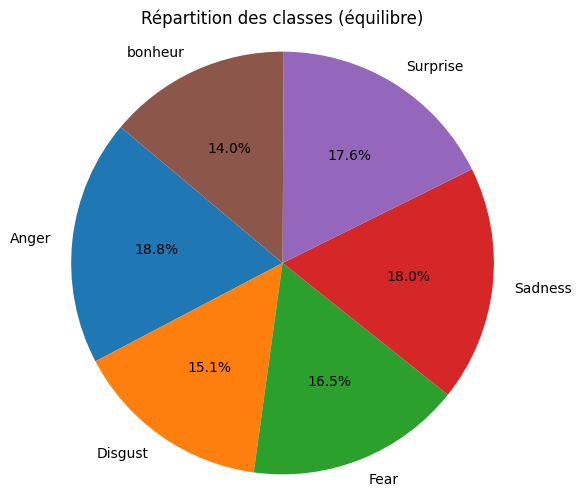

In [5]:
plot_class_distribution(y, label_dict)

In [6]:
# Afficher quelques statistiques
print(f"Nombre total d'images: {len(X)}")
print(f"Classes disponibles: {label_dict}")


Nombre total d'images: 17000
Classes disponibles: {0: 'Anger', 1: 'Disgust', 2: 'Fear', 3: 'Sadness', 4: 'Surprise', 5: 'bonheur'}


In [7]:
NUM_CLASSES = len(os.listdir(DATA_DIR))  # Nombre de classes (émotions)
NUM_CLASSES

6

In [8]:
# Prétraitement supplémentaire
from tensorflow.keras.utils import to_categorical
X = X.reshape(X.shape[0], IMG_SIZE[0], IMG_SIZE[1], 1)  # Ajouter une dimension pour le canal
y = to_categorical(y, NUM_CLASSES)  # Encodage one-hot

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [10]:
print("Nombre d'images \n Train:", X_train.shape[0], 
      "\n Test:", X_test.shape[0], 
      "\n Validation:", X_val.shape[0])


Nombre d'images 
 Train: 10880 
 Test: 3400 
 Validation: 2720


In [11]:


# Maintenant vous pouvez créer votre générateur d'augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Adaptez vos données (supposant que X_train est déjà défini)
train_datagen.fit(X_train)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

def create_optimized_model(input_shape, num_classes):
    model = Sequential()
    
    # Bloc 1
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', 
                    kernel_regularizer=regularizers.l2(1e-4),
                    input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                    kernel_regularizer=regularizers.l2(1e-4)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    
    # Bloc 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                    kernel_regularizer=regularizers.l2(1e-4)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                    kernel_regularizer=regularizers.l2(1e-4)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.35))
    
    # Bloc 3
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                    kernel_regularizer=regularizers.l2(1e-4)))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                    kernel_regularizer=regularizers.l2(1e-4)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.4))
    
    # Couches fully connected
    model.add(Flatten())
    model.add(Dense(512, activation='relu', 
                   kernel_regularizer=regularizers.l2(1e-4)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

# Create the model first
input_shape = (48, 48, 1)  # Replace with your actual input dimensions
num_classes = 6  # Replace with your number of classes
model = create_optimized_model(input_shape, num_classes)

# Then compile it
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy', 
                      tf.keras.metrics.Precision(name='precision'),
                      tf.keras.metrics.Recall(name='recall')])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

# Finally train it
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=64),
    steps_per_epoch=len(X_train)//64,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)



Epoch 1/50


170/170 [==============================] - ETA: 0s - loss: 2.3185 - accuracy: 0.2676 - precision: 0.3042 - recall: 0.1563   

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


170/170 [==============================] - 73s 354ms/step - loss: 2.3185 - accuracy: 0.2676 - precision: 0.3042 - recall: 0.1563 - val_loss: 3.4168 - val_accuracy: 0.1596 - val_precision: 0.1596 - val_recall: 0.1596 - lr: 0.0010
Epoch 2/50
170/170 [==============================] - 58s 343ms/step - loss: 1.8254 - accuracy: 0.3580 - precision: 0.4774 - recall: 0.1835 - val_loss: 3.8154 - val_accuracy: 0.1750 - val_precision: 0.1676 - val_recall: 0.1489 - lr: 0.0010
Epoch 3/50
170/170 [==============================] - 59s 347ms/step - loss: 1.6213 - accuracy: 0.4280 - precision: 0.5997 - recall: 0.2472 - val_loss: 1.5597 - val_accuracy: 0.4489 - val_precision: 0.7956 - val_recall: 0.1474 - lr: 0.0010
Epoch 4/50
170/170 [==============================] - 60s 353ms/step - loss: 1.4665 - accuracy: 0.4867 - precision: 0.6811 - recall: 0.3085 - val_loss: 1.7681 - val_accuracy: 0.4254 - val_precision: 0.6343 - val_recall: 0.2952 - lr: 0.0010
Epoch 5/50
170/170 [==============================]

In [18]:
# 2. Paramètres du modèle (à adapter)
input_shape = (X_train.shape)  # Forme des données d'entrée   
input_shape

(10880, 48, 48, 1)

In [21]:
# Évaluation du modèle
test_loss, test_acc, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

Test Loss: 0.7260
Test Accuracy: 0.7803
Test Precision: 0.8423
Test Recall: 0.7400


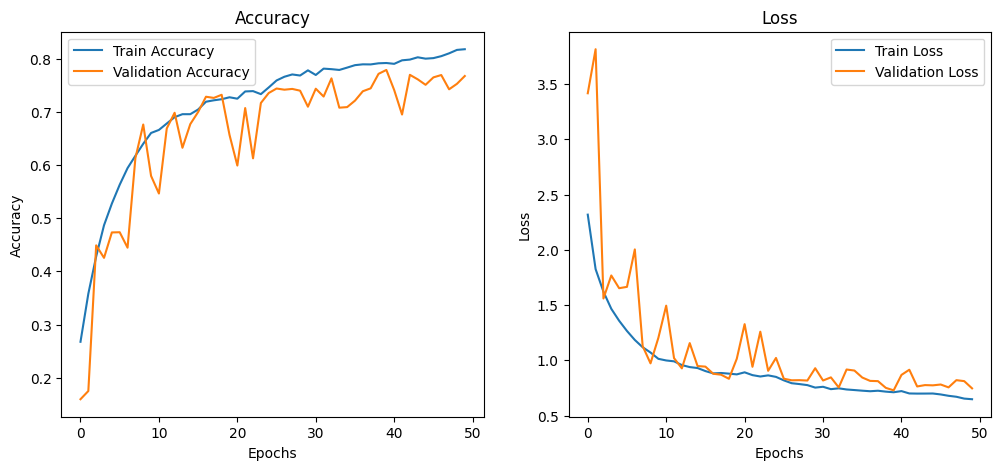

In [22]:
# Visualisation des courbes d'apprentissage
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

107/107 [==============================] - 3s 24ms/step

Rapport de classification:
              precision    recall  f1-score   support

       Anger       0.85      0.97      0.90       623
     Disgust       0.53      0.79      0.63       504
        Fear       0.64      0.59      0.61       568
     Sadness       0.88      0.56      0.69       627
    Surprise       0.93      0.89      0.91       594
     bonheur       0.98      0.90      0.94       484

    accuracy                           0.78      3400
   macro avg       0.80      0.78      0.78      3400
weighted avg       0.81      0.78      0.78      3400



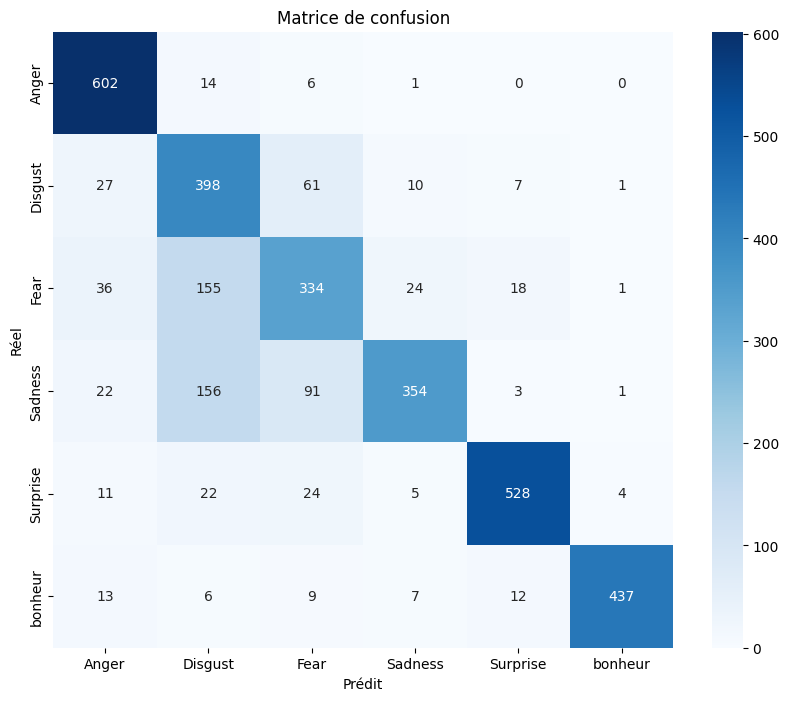

In [23]:
# Matrice de confusion et rapport de classification
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nRapport de classification:")
print(classification_report(y_true, y_pred_classes, target_names=list(label_dict.values())))

# Matrice de confusion
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), 
            annot=True, fmt='d', 
            cmap='Blues',
            xticklabels=label_dict.values(), 
            yticklabels=label_dict.values())
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()



In [ ]:
import tensorflow as tf

# Charger votre modèle entraîné
model = tf.keras.models.load_model('emotion_recognition_model.h5')

# Conversion vers TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Sauvegarder le modèle converti
with open('emotion_model.tflite', 'wb') as f:
    f.write(tflite_model)

In [ ]:
# Sauvegarde du modèle
model.save('emotion_recognition_model.h5')
print("Modèle sauvegardé sous 'emotion_recognition_model.h5'")